$Q$ (Critic): 固定されたデータから $r + \gamma V(s')$ をtargetQとして「現実的な価値」を学ぶ(損失=targetQ-Q)<br>$V$ (Value): $Q$ の上振れを追いかけて、「合格ライン（ハードル）」を高く保つ(損失=重みE×(Q-V))<br>$Actor$ (Policy): $V$ というハードルを基準に、それを超えたデータを「贔屓」して真似る(重みw=exp(β×(Q-V))として、目的=w×logπ(a|s))<br>　⇒目的の逆符号で損失にする。logπ(a|s)は経験バッファのsの時に経験バッファのaを出力する確率のlogでこれを最大化するようにactorを学習する一方で、重みwによって単に経験バッファの行動を真似るのではなくて筋のイイ行動だけを真似るようなactorになる。<br><br>IQLの学習サイクルを整理して凝縮すると以下の3行になる。<br>$Q$ を磨く: 「実績 ($r$)」と「場所の価値 ($V$)」で $Q$ を更新<br>$V$ を磨く: 「今ある $Q$」の中から「良い結果」だけを吸い上げて $V$ を更新<br>$Actor$ を磨く: 「$Q$ が $V$ より高い（＝平均より良い）」行動だけを真似る

In [ ]:
!pip install stable-baselines3==2.7.1
!pip install d3rlpy==2.8.1
!pip install gymnasium==1.2.3  # コンパチの都合でgymnasiumのバージョンを保つためにこの順番でインストールする

In [ ]:
import collections
import random

import d3rlpy
import gymnasium as gym
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import stable_baselines3 as sb3
import torch


print("d3rlpy:", d3rlpy.__version__)
print("gymnasium:", gym.__version__)
print("matplotlib:", matplotlib.__version__)
print("numpy:", np.__version__)
print("stable baselines3:", sb3.__version__)
print("pytorch:", torch.__version__)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


d3rlpy: 2.8.1
gymnasium: 1.2.3
matplotlib: 3.10.0
numpy: 2.0.2
stable baselines3: 2.7.1
pytorch: 2.10.0+cpu


In [ ]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    DEVICE_STRING = "cuda:0"
else:
    DEVICE_STRING = "cpu"

In [ ]:
class MyInventoryEnv(gym.Env):
    def __init__(self, continuous_action_flag, initial_inventory, max_step, lead_time):
        super().__init__()
        # ステップ数をカウントするため
        self.current_step = 0
        # 行動が連続的かどうか(違う場合は離散的)のフラグ
        self.continuous_action_flag = continuous_action_flag
        # 1エピソードの最大ステップ数
        self.max_step = max_step
        # 発注から納品までのリードタイム
        self.lead_time = lead_time
        # 納品待ち数を保存するキュー # 初期値は[0, 0]とする
        self.delivery_queue = collections.deque(iterable=[0]*self.lead_time,
                                                maxlen=self.lead_time)
        # 状態の初期値を定義して、状態を定義する
        self.initial_state = np.array([initial_inventory]+list(self.delivery_queue),
                                      dtype=np.float32)
        self.state = self.initial_state.copy()  # 参照渡しを防ぐためにcopy()を使う # self.stateの編集がself.initial_stateに及ばないようにするため
        # モデルがlearnやpredictメソッドの時に扱う行動(変数名はself.action_spaceがお作法)を定義
        if self.continuous_action_flag:  # 行動は連続値
            self.action_space = gym.spaces.Box(low=0,  # 発注量0～10を行動として、array形状を(1, )とする
                                               high=10,
                                               shape=(1, ),
                                               dtype=np.float32)
        else:  # 行動は離散値
            self.action_space = gym.spaces.Discrete(n=11,  # 発注量は0から11個の離散値で0～10の行動となる # array形状は( )でint扱いになる
                                                    seed=42,
                                                    start=0,
                                                    dtype=np.int32)
        # モデルがlearnやpredictメソッドの時に扱う状態(変数名はself.observation_spaceがお作法)を定義
        self.observation_space = gym.spaces.Box(low=0,  # 在庫数と納品待ち数(翌日と翌々日)として0～50の値で、array形状を(3, )とする
                                                high=50,
                                                shape=(1+self.lead_time, ),
                                                dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # 状態を初期状態にする
        self.state = self.initial_state.copy()  # 参照渡しを防ぐためにcopy()を使う # self.stateの編集がself.initial_stateに及ばないようにするため
        # キューを初期値にする
        self.delivery_queue = collections.deque(iterable=[0]*self.lead_time,
                                                maxlen=self.lead_time)
        # お作法としてinfo用の変数を作成する
        info = {}
        # ステップ数もリセットする
        self.current_step = 0
        # 初期状態とinfoを戻す
        return self.state, info

    def step(self, action):  # gymのお作法としてstep関数の引数はactionのみとする
        # ステップ数を+1する
        self.current_step = self.current_step + 1
        # 行動が連続値の時は整数部分を取得、離散値の時はそのまま
        if self.continuous_action_flag:
            preprocessed_action = np.round(a=action[0],  # 形状は(1, )なので[0]で要素を取得して四捨五入する
                                           decimals=0)
        else:
            preprocessed_action = int(action)  # そのまま(念のためint型にする)
        # 前々日に発注した数を納品する(キューの前から1つ取り出す)
        arrived_item = self.delivery_queue.popleft()
        # 需要は期待値が3のポアソン分布からサンプリングする
        demand = np.random.poisson(lam=3,
                                   size=(1, ))
        # サンプリングした需要と、納品数を踏まえて、在庫量を更新する
        inventory = np.clip(a=self.state[0] - demand[0] + arrived_item,
                            a_min=0,  # 在庫量はマイナスにはならない
                            a_max=50,  # 在庫量はself.observation_stateで定義したhigh=50を超えないようにするため
                            dtype=np.float32)
        # 行動(発注量)をキューの後ろに保存する
        self.delivery_queue.append(preprocessed_action)
        # 状態(在庫量と納品待ち数)を更新する
        self.state = np.array([inventory]+list(self.delivery_queue),
                              dtype=np.float32)
        # 在庫数15を基準として報酬を設定する # 在庫数15付近を保つように行動するようになると思う
        delta = abs(self.state[0] - 15)
        if 0 < delta < 5:
            reward = 1.0
        elif 5 <= delta < 10:
            reward = 0
        else:
            reward = - (delta * 0.1)
        # 発注を行う場合は発注コスト発生として報酬を減らす # ポアソン分布の期待値3の需要を見破られて発注を定期的に3にする事を防ぐ
        if preprocessed_action != 0:
            reward = reward - 0.5
        # 在庫量が0になった場合は在庫管理が適切でなかったとしてterminatedをtrueにする
        if self.state[0] == 0:
            terminated = True
        else:
            terminated = False
        # ステップ数が最大ステップ数になったらtruncatedをtrueにする
        if self.current_step == self.max_step:
            truncated = True
        else:
            truncated = False
        # お作法としてinfoを用意する
        info = {}
        # 状態、報酬、terminated、truncated、infoの並びで戻す
        return self.state, reward, terminated, truncated, info

In [ ]:
def collect_data_by_trained_actor(algorithm_name, env, model, timestep, deterministic_predict_flag, random_sampling_flag, random_sampling_ratio):
    state_list = []
    action_list = []
    reward_list = []
    terminated_list = []
    truncated_list = []
    state, _ = env.reset()
    for i in range(timestep):
        predicted_action, hidden = model.predict(observation=state,
                                                 deterministic=deterministic_predict_flag)
        if random_sampling_flag:  # ランダムサンプリングのフラグがTrueの場合は、
            if random.uniform(a=0, b=1.0) < random_sampling_ratio:  # 指定の確率で、
                predicted_action = env.action_space.sample()  # ランダムサンプリングの行動で上書きする
        next_state, reward, terminated, truncated, info = env.step(action=predicted_action)
        state_list.append(state)
        action_list.append(predicted_action)
        reward_list.append(reward)
        terminated_list.append(terminated)
        truncated_list.append(truncated)
        if terminated or truncated:
            state, _ = env.reset()
        else:
            state = next_state
    state_array = np.array(object=state_list,
                           dtype=np.float32)  # 形状は(timestep数, 3)
    action_array = np.array(object=action_list,
                            dtype=np.float32).reshape((-1, 1))  # 形状は(timestep数, 1)
    reward_array = np.array(object=reward_list,
                            dtype=np.float32)  # 形状は(timestep数, )
    terminated_array = np.array(object=terminated_list,
                                dtype=np.float32)  # 形状は(timestep数, )
    truncated_array = np.array(object=truncated_list,
                               dtype=np.float32)  # 形状は(timestep数, )
    return (state_array, action_array, reward_array, terminated_array, truncated_array)

In [ ]:
def inference_timestep(algorithm_name, env, model, timestep):
    state, _ = env.reset()
    total_reward = 0
    inventory_list = []
    available_inventory_list = []
    for i in range(timestep):
        print("{a}:{b}ステップ: 在庫量:{c} 翌納品:{d} 翌々納品(action):{e}".format(a=algorithm_name, b=i, c=state[0], d=state[1], e=state[2]))
        inventory_list.append(state[0])
        available_inventory_list.append(state[0]+state[1]+state[2])
        if algorithm_name in ["IQL", "CQL-SAC", "CQL-DDQN"]:
            state = state.reshape(1, -1)  # d3rlpyライブラリーのモデルは入力データにバッチ軸を求めるので、形状を(3, )から(1, 3)に変える
            # https://d3rlpy.readthedocs.io/en/latest/references/algos.html#d3rlpy.algos.QLearningAlgoBase.predict
            predicted_action = model.predict(x=state)  # 出力の形状は(1, 1) # (入力したstateの時系列数, actionの次元数)
            predicted_action = predicted_action[0]  # [0]で取得して(1, )にする # env.stepでは行動の形状は(1, )を想定しているため
        else:
            predicted_action, hidden = model.predict(observation=state,
                                                     deterministic=True)
        next_state, reward, terminated, truncated, info = env.step(action=predicted_action)
        total_reward = total_reward + reward
        if terminated or truncated:
            break
        state = next_state
    print("{a}:報酬合計:{b}".format(a=algorithm_name, b=total_reward))
    return inventory_list, available_inventory_list

In [ ]:
# 経験バッファにはSACで推論した行動のデータを保存するために、まずは環境からのデータを使ってSACを学習する
env_sac = MyInventoryEnv(continuous_action_flag=True,  # SACは連続的な行動を対象とする
                         initial_inventory=20,
                         max_step=31,
                         lead_time=2)
# https://stable-baselines3.readthedocs.io/en/master/modules/sac.html#stable_baselines3.sac.SAC
model_sac = sb3.SAC(policy="MlpPolicy",
                    env=env_sac,
                    learning_rate=0.0003,
                    buffer_size=2048,  # 経験バッファに保存するステップ数
                    learning_starts=64,  # 学習を開始する経験バッファ保存ステップ数
                    batch_size=64,
                    tau=0.005,  # ターゲットcriticのパラメータ更新を、criticのパラメータで行う割合
                    gamma=0.98,  # critic学習で正解データとなるターゲットQを算出する際の割引率
                    train_freq=1,  # 経験バッファにlearning_startsステップ数保存されて以降、何ステップ毎にactorとcriticの学習を行うか
                    ent_coef="auto",  # actor学習での損失値の算出や、critic学習でのターゲットQの算出にて、actorの推論による方策のエントロピー(ランダム性の尺度:−logπ(a∣s))を盛り込む割合(autoだと学習して動的な値になる)
                    target_update_interval=1,  # criticのパラメータ更新に伴って、ターゲットcriticを更新する間隔(1ならばcriticを学習するとターゲットcriticも学習する)
                    # verbose=1,
                    device=DEVICE)
model_sac.learn(total_timesteps=51200,
                progress_bar=True)

Output()

In [ ]:
datas_array = collect_data_by_trained_actor(algorithm_name="sac",  # 学習したSACによる推論の行動で経験バッファ用のデータを環境から収集する # 行動は連続的
                                            env=env_sac,
                                            model=model_sac,
                                            timestep=50000,  # 50000件のデータを収集する
                                            deterministic_predict_flag=True,  # Trueは決定的(最も高い確率になるμの行動)、Falseは確率的(μとσでの正規分布からのランダムサンプリング)
                                            random_sampling_flag=False,  # 一部の行動をランダムサンプリングにするかどうか
                                            random_sampling_ratio=0.1)  # ランダムサンプリングにする確率
dataset_iql = d3rlpy.dataset.MDPDataset(observations=datas_array[0],
                                        actions=datas_array[1],
                                        rewards=datas_array[2],
                                        terminals=datas_array[3],
                                        timeouts=datas_array[4])

2026-04-26 12:49.45 [info     ] Signatures have been automatically determined. action_signature=Signature(dtype=[dtype('float32')], shape=[(1,)]) observation_signature=Signature(dtype=[dtype('float32')], shape=[(3,)]) reward_signature=Signature(dtype=[dtype('float32')], shape=[(1,)])
2026-04-26 12:49.45 [info     ] Action-space has been automatically determined. action_space=<ActionSpace.CONTINUOUS: 1>
2026-04-26 12:49.45 [info     ] Action size has been automatically determined. action_size=1


In [ ]:
# https://d3rlpy.readthedocs.io/en/latest/references/algos.html#d3rlpy.algos.IQLConfig
# Q(critic)の損失値は「報酬 ＋ 割引率 × V(n+1)」をtargetQとして「targetQ － Q」
#  ⇒正しい行動価値Qを出せるように学習する
# V(critic)の損失値は「重みE × (Q － V)」
#  ⇒閾値的な役割とする状態価値Vを、行動価値Qに近づくように学習する。その際に100%のQでなく、重みE=0.8を用いる事で80%のQに近づくようにする
# actorの目的値は「exp(β × (Q － V))」を重みwとして「w × logπ(a|s)」
#  ⇒損失値は逆符号。logπ(a|s)は経験バッファsで経験バッファaを推論する確率のlogで、QがVより高い場合のπを高めるような学習になる
model_config_iql = d3rlpy.algos.IQLConfig(batch_size=256,
                                          gamma=0.99,  # Q(critic)の損失値を求める際のターゲットQを算出する時の割引率
                                          actor_learning_rate=0.00003,  # actorの学習率
                                          critic_learning_rate=0.0005,  # Qcriticの学習率
                                          tau=0.005,  # ターゲットcriticを更新する際のcriticパラメータを盛り込む割合
                                          n_critics=2,  # criticとターゲットcriticのペアの数(2ならばcriticが2つのターゲットcriticが2つの合計4つ)
                                          expectile=0.8,  # V(critic)の損失値での重みE
                                          weight_temp=10.0)  # actorの目的値のβ
model_iql = model_config_iql.create(device=DEVICE_STRING)

In [ ]:
# https://d3rlpy.readthedocs.io/en/latest/references/algos.html#d3rlpy.algos.QLearningAlgoBase.fit
model_iql.fit(dataset=dataset_iql,
              n_steps=50000,
              n_steps_per_epoch=1000,
              with_timestamp=True,
              show_progress=True)

2026-04-26 14:03.44 [info     ] dataset info                   dataset_info=DatasetInfo(observation_signature=Signature(dtype=[dtype('float32')], shape=[(3,)]), action_signature=Signature(dtype=[dtype('float32')], shape=[(1,)]), reward_signature=Signature(dtype=[dtype('float32')], shape=[(1,)]), action_space=<ActionSpace.CONTINUOUS: 1>, action_size=1)
2026-04-26 14:03.44 [debug    ] Building models...            
2026-04-26 14:03.44 [debug    ] Models have been built.       
2026-04-26 14:03.44 [info     ] Directory is created at d3rlpy_logs/IQL_20260426140344
2026-04-26 14:03.44 [info     ] Parameters                     params={'observation_shape': [3], 'action_size': 1, 'config': {'type': 'iql', 'params': {'batch_size': 256, 'gamma': 0.99, 'observation_scaler': {'type': 'none', 'params': {}}, 'action_scaler': {'type': 'none', 'params': {}}, 'reward_scaler': {'type': 'none', 'params': {}}, 'compile_graph': False, 'actor_learning_rate': 3e-05, 'critic_learning_rate': 0.0005, 'actor_op

Epoch 1/50:   0%|          | 0/1000 [00:00<?, ?it/s]

2026-04-26 14:04.19 [info     ] IQL_20260426140344: epoch=1 step=1000 epoch=1 metrics={'time_sample_batch': 0.0050922737121582035, 'time_algorithm_update': 0.029535712003707887, 'critic_loss': 0.594434451341629, 'q_loss': 0.5858093214333058, 'v_loss': 0.008625129311694764, 'actor_loss': 236.58753558430857, 'time_step': 0.03477607297897339} step=1000
2026-04-26 14:04.19 [info     ] Model parameters are saved to d3rlpy_logs/IQL_20260426140344/model_1000.d3


Epoch 2/50:   0%|          | 0/1000 [00:00<?, ?it/s]

2026-04-26 14:04.55 [info     ] IQL_20260426140344: epoch=2 step=2000 epoch=2 metrics={'time_sample_batch': 0.005081775665283203, 'time_algorithm_update': 0.03034391975402832, 'critic_loss': 0.5637393780052662, 'q_loss': 0.5517230671346187, 'v_loss': 0.012016310340724885, 'actor_loss': 431.28887910223006, 'time_step': 0.035567320108413694} step=2000
2026-04-26 14:04.55 [info     ] Model parameters are saved to d3rlpy_logs/IQL_20260426140344/model_2000.d3


...

Epoch 49/50:   0%|          | 0/1000 [00:00<?, ?it/s]

2026-04-26 14:34.36 [info     ] IQL_20260426140344: epoch=49 step=49000 epoch=49 metrics={'time_sample_batch': 0.005126530885696411, 'time_algorithm_update': 0.03361753940582275, 'critic_loss': 0.9226433643698693, 'q_loss': 0.9107512331604958, 'v_loss': 0.011892132550827227, 'actor_loss': 14.104617192834615, 'time_step': 0.038892009973526} step=49000
2026-04-26 14:34.36 [info     ] Model parameters are saved to d3rlpy_logs/IQL_20260426140344/model_49000.d3


Epoch 50/50:   0%|          | 0/1000 [00:00<?, ?it/s]

2026-04-26 14:35.15 [info     ] IQL_20260426140344: epoch=50 step=50000 epoch=50 metrics={'time_sample_batch': 0.005110335350036621, 'time_algorithm_update': 0.0337138831615448, 'critic_loss': 0.909759003162384, 'q_loss': 0.8946802936792374, 'v_loss': 0.015078708926099353, 'actor_loss': 14.955660762667655, 'time_step': 0.03896608519554138} step=50000
2026-04-26 14:35.15 [info     ] Model parameters are saved to d3rlpy_logs/IQL_20260426140344/model_50000.d3


[(1,
  {'time_sample_batch': 0.0050922737121582035,
   'time_algorithm_update': 0.029535712003707887,
   'critic_loss': 0.594434451341629,
   'q_loss': 0.5858093214333058,
   'v_loss': 0.008625129311694764,
   'actor_loss': 236.58753558430857,
   'time_step': 0.03477607297897339}),
 (2,
  {'time_sample_batch': 0.005081775665283203,
   'time_algorithm_update': 0.03034391975402832,
   'critic_loss': 0.5637393780052662,
   'q_loss': 0.5517230671346187,
   'v_loss': 0.012016310340724885,
   'actor_loss': 431.28887910223006,
   'time_step': 0.035567320108413694}),
 (3,
  {'time_sample_batch': 0.0050709969997406006,
   'time_algorithm_update': 0.030548305988311767,
   'critic_loss': 0.6349349774718285,
   'q_loss': 0.6237387041151523,
   'v_loss': 0.011196272764820606,
   'actor_loss': 515.3708548619747,
   'time_step': 0.03576532411575317}),
 (4,
  {'time_sample_batch': 0.00488772988319397,
   'time_algorithm_update': 0.0303829128742218,
   'critic_loss': 0.6531182408332825,
   'q_loss': 0.

IQL:0ステップ: 在庫量:20.0 翌納品:0.0 翌々納品(action):0.0
IQL:1ステップ: 在庫量:17.0 翌納品:0.0 翌々納品(action):1.0
IQL:2ステップ: 在庫量:17.0 翌納品:1.0 翌々納品(action):1.0
IQL:3ステップ: 在庫量:15.0 翌納品:1.0 翌々納品(action):1.0
IQL:4ステップ: 在庫量:13.0 翌納品:1.0 翌々納品(action):1.0
IQL:5ステップ: 在庫量:8.0 翌納品:1.0 翌々納品(action):1.0
IQL:6ステップ: 在庫量:2.0 翌納品:1.0 翌々納品(action):1.0
IQL:報酬合計:-3.3000001907348633
SAC:0ステップ: 在庫量:20.0 翌納品:0.0 翌々納品(action):0.0
SAC:1ステップ: 在庫量:18.0 翌納品:0.0 翌々納品(action):7.0
SAC:2ステップ: 在庫量:14.0 翌納品:7.0 翌々納品(action):0.0
SAC:3ステップ: 在庫量:18.0 翌納品:0.0 翌々納品(action):0.0
SAC:4ステップ: 在庫量:18.0 翌納品:0.0 翌々納品(action):9.0
SAC:5ステップ: 在庫量:17.0 翌納品:9.0 翌々納品(action):0.0
SAC:6ステップ: 在庫量:21.0 翌納品:0.0 翌々納品(action):0.0
SAC:7ステップ: 在庫量:15.0 翌納品:0.0 翌々納品(action):4.0
SAC:8ステップ: 在庫量:11.0 翌納品:4.0 翌々納品(action):8.0
SAC:9ステップ: 在庫量:6.0 翌納品:8.0 翌々納品(action):0.0
SAC:10ステップ: 在庫量:11.0 翌納品:0.0 翌々納品(action):8.0
SAC:11ステップ: 在庫量:9.0 翌納品:8.0 翌々納品(action):10.0
SAC:12ステップ: 在庫量:12.0 翌納品:10.0 翌々納品(action):0.0
SAC:13ステップ: 在庫量:18.0 翌納品:0.0 翌々納品(action):1.0
SAC:14ステップ: 在庫量:15.0 翌納品

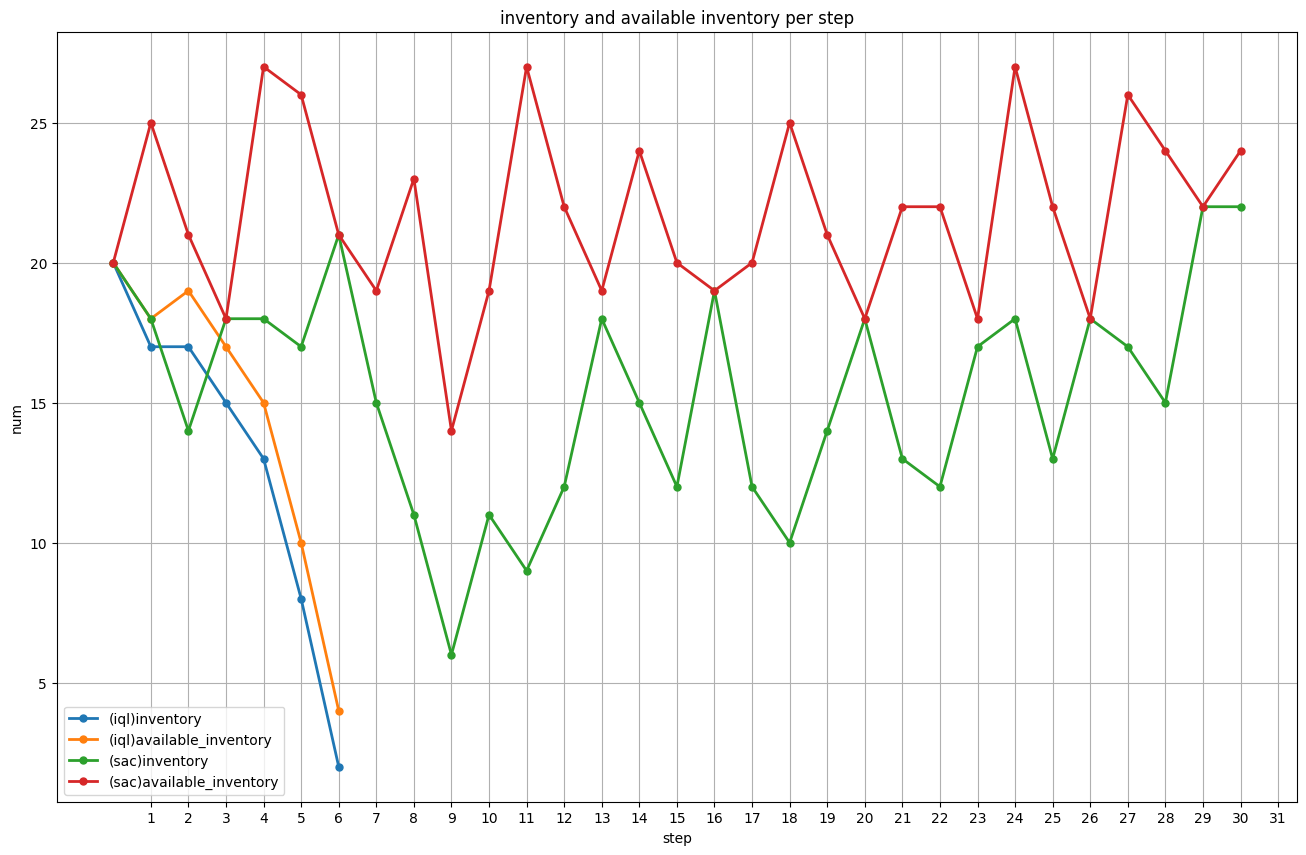

In [ ]:
env_iql = MyInventoryEnv(continuous_action_flag=True,
                         initial_inventory=20,
                         max_step=31,
                         lead_time=2)
inventory_list_iql, available_inventory_list_iql = inference_timestep(algorithm_name="IQL",
                                                                      env=env_iql,
                                                                      model=model_iql,
                                                                      timestep=31)
inventory_list_sac, available_inventory_list_sac = inference_timestep(algorithm_name="SAC",
                                                                      env=env_sac,
                                                                      model=model_sac,
                                                                      timestep=31)
fig, (ax1) = plt.subplots(nrows=1, ncols=1, figsize=(16, 10))
ax1.plot(np.arange(stop=len(inventory_list_iql)),
         inventory_list_iql,
         label="(iql)inventory",
         marker="o",
         markersize=5,
         linestyle="solid",
         linewidth=2)
ax1.plot(np.arange(stop=len(available_inventory_list_iql)),
         available_inventory_list_iql,
         label="(iql)available_inventory",
         marker="o",
         markersize=5,
         linestyle="solid",
         linewidth=2)
ax1.plot(np.arange(stop=len(inventory_list_sac)),
         inventory_list_sac,
         label="(sac)inventory",
         marker="o",
         markersize=5,
         linestyle="solid",
         linewidth=2)
ax1.plot(np.arange(stop=len(available_inventory_list_sac)),
         available_inventory_list_sac,
         label="(sac)available_inventory",
         marker="o",
         markersize=5,
         linestyle="solid",
         linewidth=2)
ax1.legend(loc=0)
ax1.set_title(label="inventory and available inventory per step")
ax1.set_xlabel(xlabel="step")
ax1.set_ylabel(ylabel="num")
ax1.set_xticks(ticks=np.arange(stop=len(inventory_list_sac))+1)
ax1.grid(True)
plt.show()

IQLでも行動は1ばかりになってしまった<br>⇒Q(critic)やV(critic)の推論結果をactorの目的関数の重みに用いているので、本来はQ(critic)やV(critic)で目的値の高いものがactorにとっても目的値の高いものになっていくはずだけれど、正解データの経験バッファには行動0のデータがあまりにも多い<br>⇒そうなると、まだQ(critic)やV(critic)では行動0と行動8で目的値に大差無いけれど、actorにとっては目的関数のlogπ(a|s)によって行動0で目的値が高く(行動0で損失値が低く)なり、Q(critic)やV(critic)がそれなりに学習される前に、actorは行動0を出す形で学習されてしまうのかもしれない<br>⇒行動1になっているのは、actorの出力は連続値であり、正解データの経験バッファに行動8などのデータもあるので、actorは0でなく0.5とか0.6とかを出力して、その結果として行動1という形になっていると思われる<br>⇒それを踏まえると、CQLのオフライン学習では正解データでデータ不均衡があったりするとそこまでイイ形のモデルにはならないのかもしれない